In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import os
import torch
import numpy as np
import copy
import warnings
from torch.utils.tensorboard import SummaryWriter
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import pandas as pd
from scipy.ndimage import gaussian_filter1d

warnings.filterwarnings("ignore", category=UserWarning)

# 导入解耦后的模块
from configs.default_config import Config
from envs.hems_env import EnergyStorageEnv
from common.replay_buffer import ReplayBuffer
from madrl.maddpg import MADDPG
from madrl.matd3 import MATD3
from common.vec_env import DummyVecEnv  # 导入我们编写的多进程环境

warnings.filterwarnings("ignore", category=UserWarning)
# 初始化配置
args = Config()
obs_config = ["time","price","load","soc","soc_margin","action_bounds","global_summary","future_price","future_load"]
# 可以顺手把 future 相关的长度设为 0，保持配置严谨
# args.future_price = 0
# args.future_load = 0

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [2]:
class Runner:
    def __init__(self, args, env_name, number, seed):
        self.args = args
        self.env_name = env_name
        
        # --- 使用多进程向量化环境 (训练用) ---
        self.env = DummyVecEnv(args.num_envs, EnergyStorageEnv, args, mode='train')
        self.env_evaluate = EnergyStorageEnv(args, mode='test')
        
        # 补齐你 Agent 需要的额外参数 (从单环境中提取维度信息)
        self.args.N = self.args.num_agents
        self.args.obs_dim_n = [self.env_evaluate.observation_space[i].shape[0] for i in range(self.args.N)]
        self.args.action_dim_n = [self.env_evaluate.action_space[i].shape[0] for i in range(self.args.N)]
        
        np.random.seed(seed)
        torch.manual_seed(seed)

        if self.args.algorithm == "MADDPG":
            self.agent_n = [MADDPG(args, i) for i in range(args.N)]
        elif self.args.algorithm == "MATD3":
            self.agent_n = [MATD3(args, i) for i in range(args.N)]

        self.replay_buffer = ReplayBuffer(self.args)
        self.writer = SummaryWriter(log_dir=f'runs/{self.args.algorithm}_{env_name}_{number}_seed_{seed}')
        
        self.history = []
        self.episode_rewards = []
        self.total_steps = 0
        self.noise_std = self.args.noise_std_init

    def _init_env_history(self):
        """为每个独立的并行环境初始化一个数据记录字典，以兼容画图需求"""
        return {
            'actions': [[] for _ in range(self.args.N)],
            # 预先塞入初始 SOC，保证长度为 97，匹配画图代码里的 [1:]
            'soc': [[self.args.init_soc] for _ in range(self.args.N)], 
            'price': [],
            'original_load': [],
            'net_load': [],
            'original_load_cost': [],
            'ess_profit': [],
            'soc_penalty': [],
            'peak_valley_penalty': [],
            'cost_with_ess': []
        }

    def save_model(self, model_dir, episode):
        algo_model_dir = os.path.join(model_dir, self.args.algorithm)
        if not os.path.exists(algo_model_dir):
            os.makedirs(algo_model_dir)
        for agent in self.agent_n:
            agent.save_model(algo_model_dir, episode)
        print(f"Models saved to {algo_model_dir}")

    def load_model(self, model_dir, episode):
        algo_model_dir = os.path.join(model_dir, self.args.algorithm)
        for agent in self.agent_n:
            agent.load_model(algo_model_dir, episode)
        print(f"Models loaded from {algo_model_dir}")

    def run(self):
        # 目标交互次数 = 总步数 / 环境数量
        target_interactions = self.args.max_train_steps // self.args.num_envs
        interaction_step = 0
        episodes_completed = 0
        
        # 预先为每个环境建立一个记录账本
        active_histories = [self._init_env_history() for _ in range(self.args.num_envs)]
        active_ep_rewards = np.zeros(self.args.num_envs)

        pbar = tqdm(total=target_interactions, desc='Training (Parallel)', unit='iters')
        
        try:
            obs_n = self.env.reset()
            
            while interaction_step < target_interactions:
                # 1. 批量获取动作
                a_n = [agent.choose_action(obs, noise_std=self.noise_std) for agent, obs in zip(self.agent_n, obs_n)]
                
                # 2. 与并行环境交互
                obs_next_n, r_n, done_n, info_list = self.env.step(a_n)
                
                # 3. 记录物理数据到各自的账本中
                for env_idx in range(self.args.num_envs):
                    info = info_list[env_idx]
                    hist = active_histories[env_idx]
                    
                    hist['price'].append(info['price'])
                    hist['original_load'].append(info['original_total_load'])
                    hist['net_load'].append(info['net_total_load'])
                    hist['original_load_cost'].append(info['original_load_cost'])
                    hist['ess_profit'].append(info['ess_profit'])
                    hist['soc_penalty'].append(info['soc_penalty'])
                    hist['peak_valley_penalty'].append(info['peak_valley_penalty'])
                    hist['cost_with_ess'].append(info['cost_with_ess'])
                    
                    for i in range(self.args.N):
                        hist['actions'][i].append(float(a_n[i][env_idx][0]))
                        hist['soc'][i].append(info['soc'][i])
                        
                    # 计算该环境的总奖励
                    step_reward = sum([r_n[agent_id][env_idx][0] for agent_id in range(self.args.N)])
                    active_ep_rewards[env_idx] += step_reward

                # 4. 批量存入经验回放池
                self.replay_buffer.store_transitions_batched(obs_n, a_n, r_n, obs_next_n, done_n)
                
                obs_n = obs_next_n
                interaction_step += 1
                self.total_steps += self.args.num_envs

                # 5. 处理回合结束逻辑 (自动重置)
                for env_idx in range(self.args.num_envs):
                    if info_list[env_idx].get('episode_done', False):
                        # 为了避免内存溢出，最多保留最近 2000 个回合的画图数据
                        if len(self.history) >= 2000:
                            self.history.pop(0)
                        self.history.append(active_histories[env_idx])
                        
                        ep_reward = active_ep_rewards[env_idx]
                        self.episode_rewards.append(ep_reward)
                        self.writer.add_scalar('train_episode_rewards', ep_reward, global_step=self.total_steps)
                        
                        # 清空该环境的账本
                        active_histories[env_idx] = self._init_env_history()
                        active_ep_rewards[env_idx] = 0.0
                        episodes_completed += 1

                # 6. 噪声衰减
                if self.args.use_noise_decay:
                    self.noise_std = max(self.noise_std - self.args.noise_std_decay, self.args.noise_std_min)

                # 7. 控制更新频率
                if self.replay_buffer.current_size > self.args.batch_size and interaction_step % self.args.update_interval == 0:
                    for _ in range(self.args.updates_per_step):
                        for agent_id in range(self.args.N):
                            self.agent_n[agent_id].train(self.replay_buffer, self.agent_n)

                pbar.update(1)
                if len(self.episode_rewards) > 0:
                    avg_reward = np.mean(self.episode_rewards[-50:])
                    pbar.set_postfix({'avg_reward': f'{avg_reward:.2f}', 'steps': self.total_steps})

        finally:
            pbar.close()
            self.env.close()
            self.env_evaluate.close()

        return episodes_completed



In [3]:
if __name__ == '__main__':
    # 强制设置多进程启动方式为 spawn (Jupyter 中加上这句更稳妥)
    import multiprocessing as mp
    try:
        mp.set_start_method('spawn')
    except RuntimeError:
        pass # 如果已经设置过，会抛出 RuntimeError，直接忽略即可

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    
    # 实例化并运行
    runner = Runner(args, env_name="EnergyStorageEnv", number=1, seed=0)
    # ==========================================
    # ★ 观测空间探查与验证 (Inspection)
    # ==========================================
    print("\n" + "="*40)
    print("🧐 观测空间 (Observation Space) 探查")
    print("="*40)

    # 1. 查看当前启用的特征列表
    print(f"启用的特征组合: {runner.args.obs_config}")

    # 2. 查看具体的维度大小
    obs_dim = runner.args.obs_dim_n[0]
    print(f"每个智能体的观测向量总维度: {obs_dim} 维")

    # 导师的物理意义拆解提示：
    print("-> 维度拆解物理意义: ")
    print("   - Time  (2维): 使用 sin 和 cos 编码一天中的当前步数，保证 23:45 到 00:00 的特征是连续的。")
    print("   - Price (1维): 当前时刻的标准化电价 (norm_price)。")
    print("   - Load  (1维): 当前时刻的标准化负荷 (norm_load)。")
    print("   - SOC   (1维): 当前时刻电池的荷电状态 (0.05 ~ 0.95)。")
    print(f"-> 理论总计: 2 + 1 + 1 + 1 = 5 维。当前实际维度: {obs_dim} 维。")

    # 3. 打印实际传给神经网络的 Tensor 样例
    sample_obs_n = runner.env.reset()
    # sample_obs_n 是一个列表，包含了 N 个智能体的数据
    agent_0_obs_batched = sample_obs_n[0] # 取出 1 号智能体 (Agent 0) 的观测批次

    print(f"\n传入神经网络的 Batched 张量形状: {agent_0_obs_batched.shape} -> (num_envs, obs_dim)")

    # 取出第一个并行环境 (Env 0) 里的实际观测数值
    single_env_obs = agent_0_obs_batched[0]
    print(f"单个环境实际采样的观测向量值 (Agent 0, Env 0):\n{single_env_obs}\n")

    print("="*40 + "\n")

    trained_episodes = runner.run()

    # 保存模型
    model_save_dir = "./saved_models"
    final_episode = getattr(args, 'train_episodes', trained_episodes)
    runner.save_model(model_save_dir, episode=final_episode)



Using device: cuda
------use_orthogonal_init------
------use_orthogonal_init------
------use_orthogonal_init------
------use_orthogonal_init------
------use_orthogonal_init------
------use_orthogonal_init------

🧐 观测空间 (Observation Space) 探查
启用的特征组合: ['time', 'price', 'load', 'soc', 'soc_margin', 'action_bounds', 'global_summary', 'future_price', 'future_load']
每个智能体的观测向量总维度: 60 维
-> 维度拆解物理意义: 
   - Time  (2维): 使用 sin 和 cos 编码一天中的当前步数，保证 23:45 到 00:00 的特征是连续的。
   - Price (1维): 当前时刻的标准化电价 (norm_price)。
   - Load  (1维): 当前时刻的标准化负荷 (norm_load)。
   - SOC   (1维): 当前时刻电池的荷电状态 (0.05 ~ 0.95)。
-> 理论总计: 2 + 1 + 1 + 1 = 5 维。当前实际维度: 60 维。

传入神经网络的 Batched 张量形状: (32, 60) -> (num_envs, obs_dim)
单个环境实际采样的观测向量值 (Agent 0, Env 0):
[ 0.0000000e+00  1.0000000e+00  5.9742582e-01  3.4582820e-02
  5.0000001e-02  8.9999998e-01  7.4505807e-10  1.0000000e-01
  0.0000000e+00 -9.7961611e-01  5.8093888e-01  7.2099787e-01
  5.9742582e-01  8.6129797e-01  8.6129797e-01  8.6129797e-01
  8.6129797e-01  2.0352981e+00  2

Training (Parallel):   0%|          | 0/3000 [00:00<?, ?iters/s]

Models saved to ./saved_models\MADDPG


--- Plotting Training Process Analysis ---


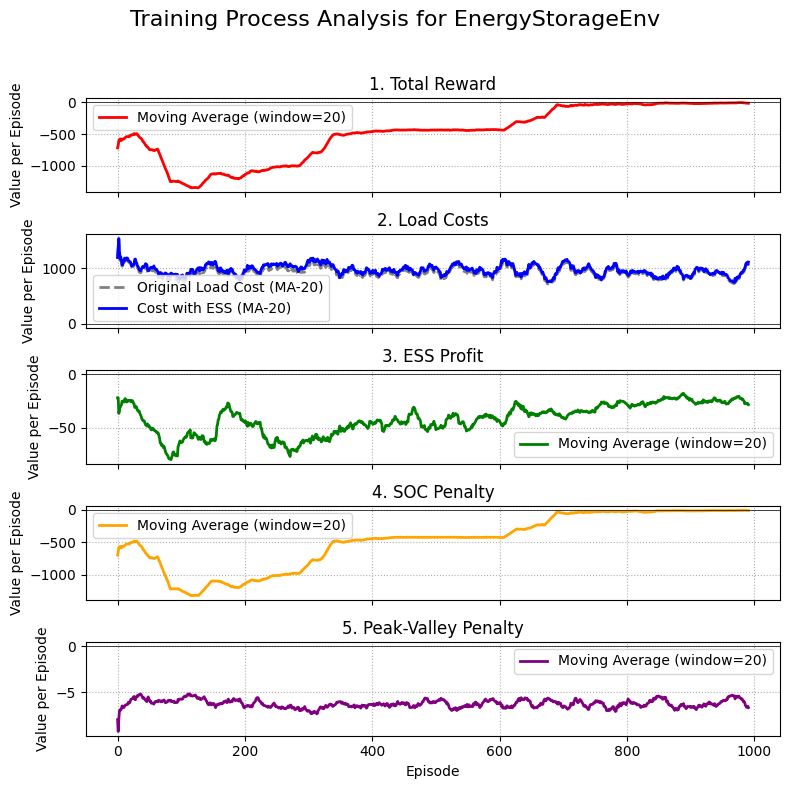


--- Plotting Detailed Results ---
Episodes to plot (1-based): [1, 331, 662, 992]


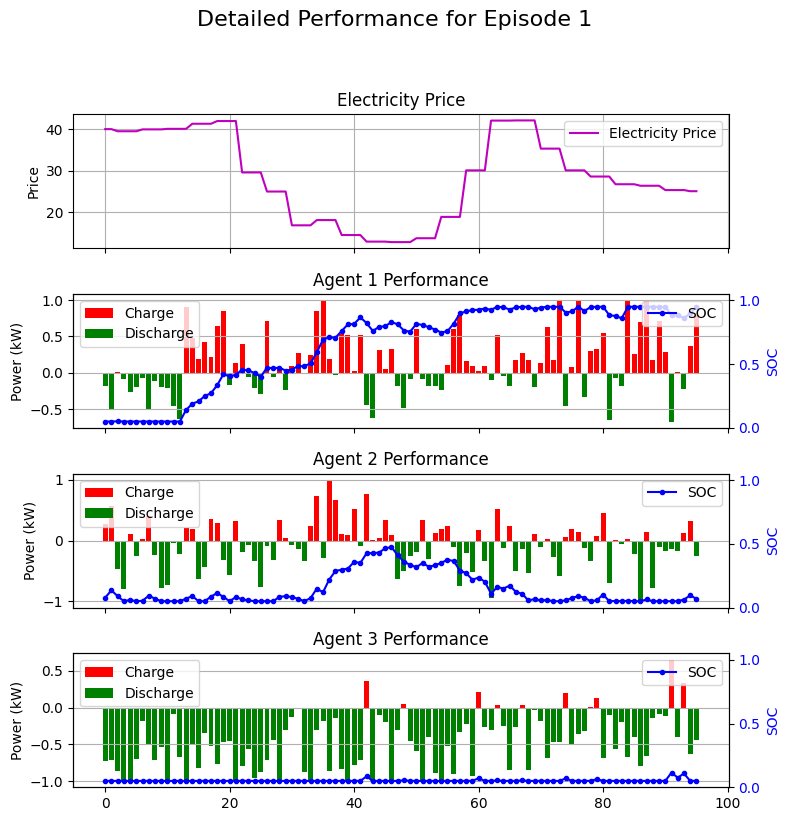

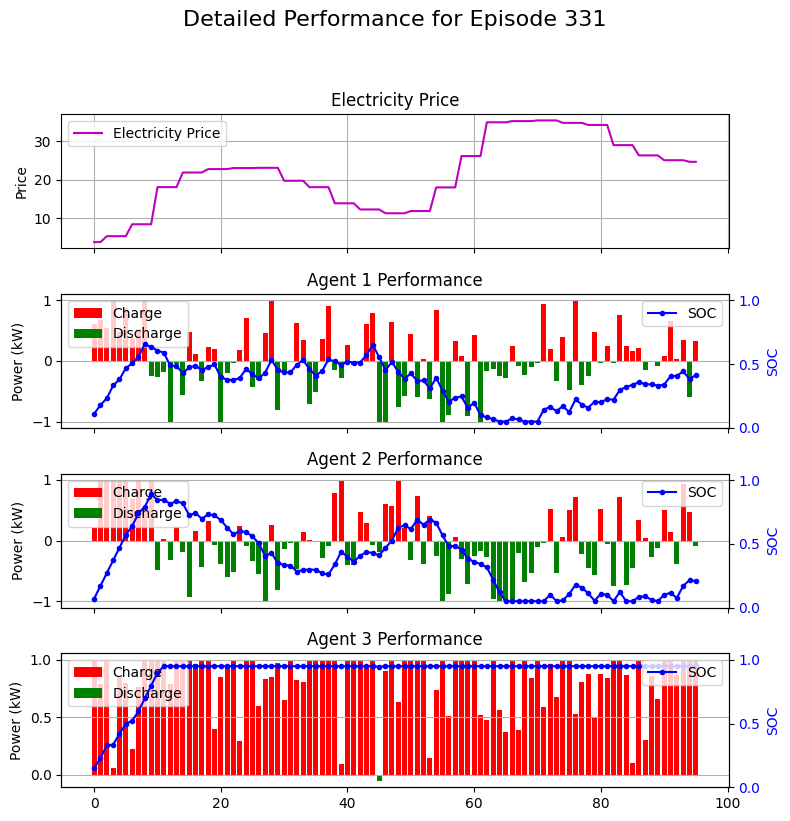

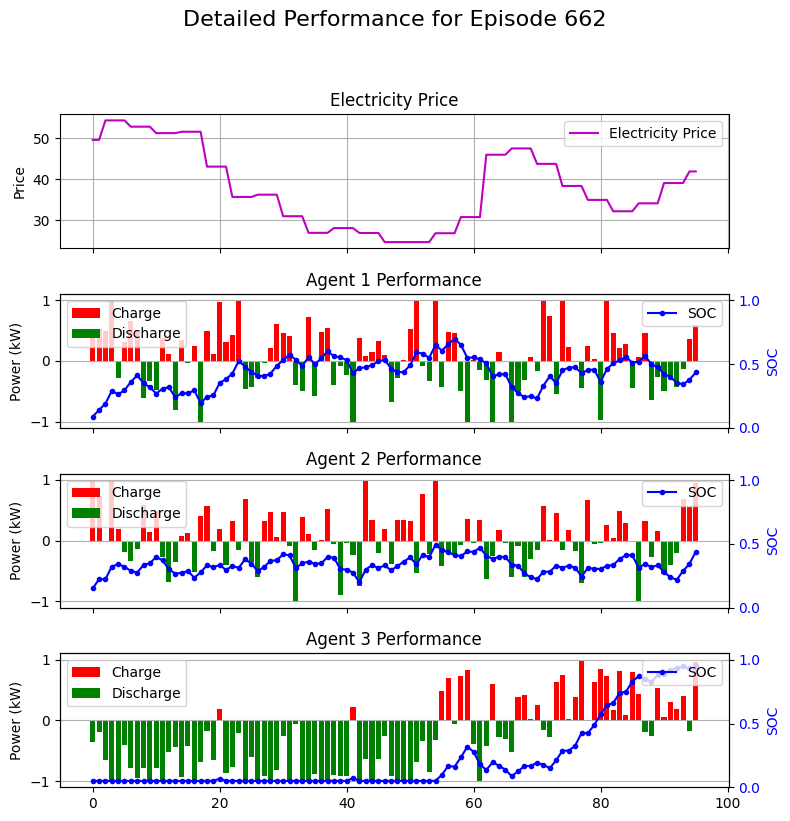

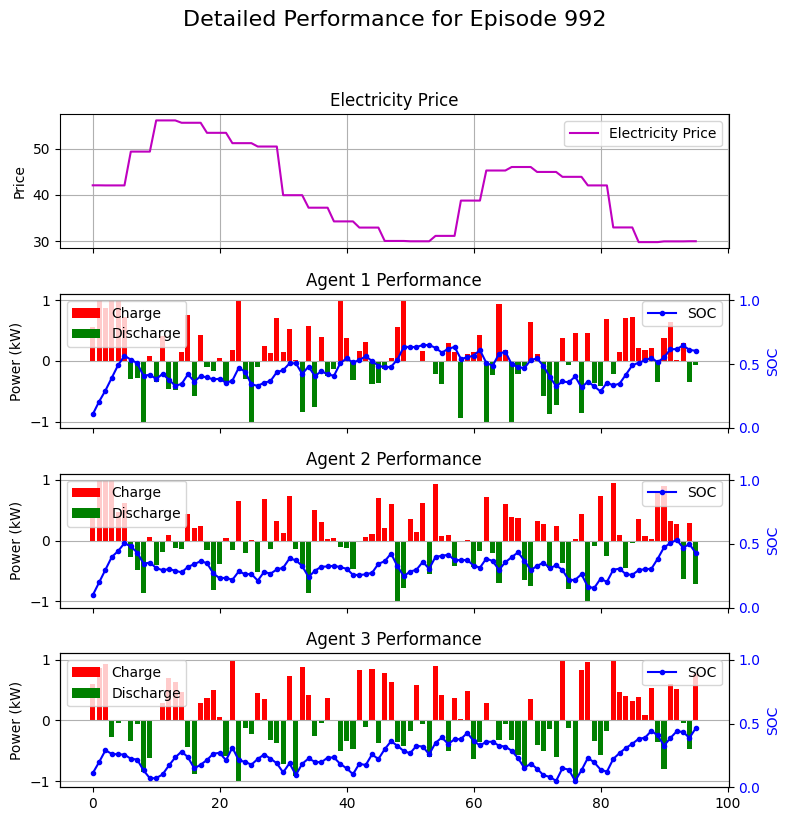


--- Plotting Detailed Results ---
Episodes to plot (1-based): [1, 331, 662, 992]


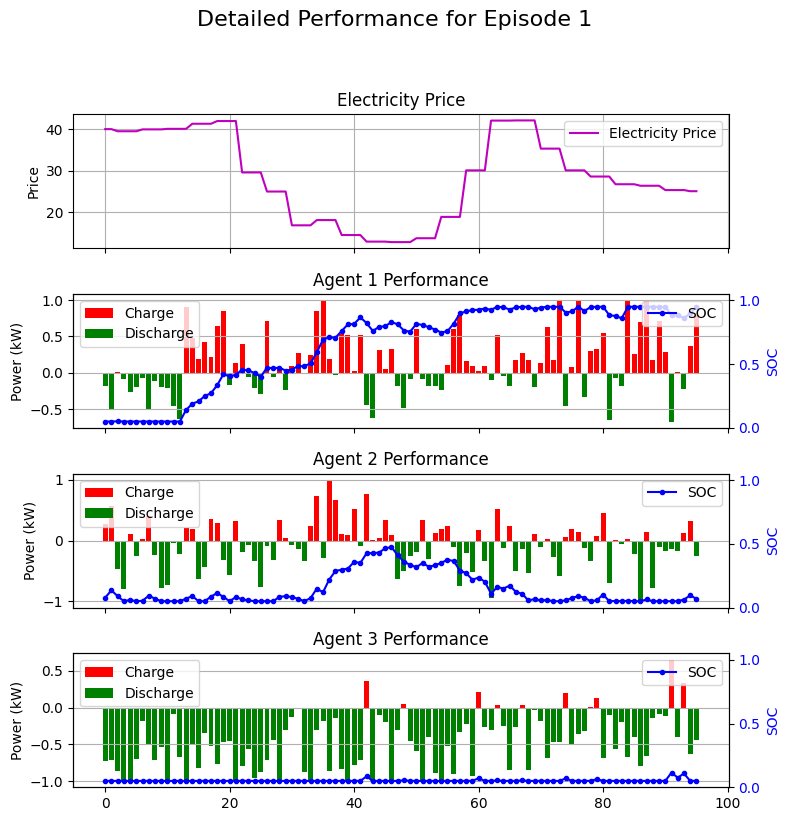

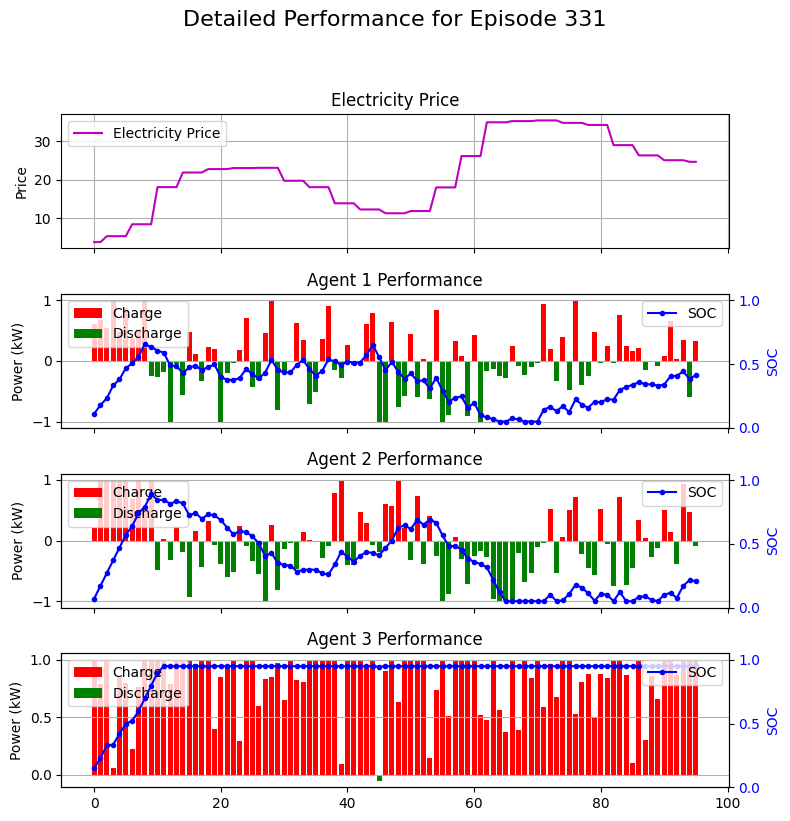

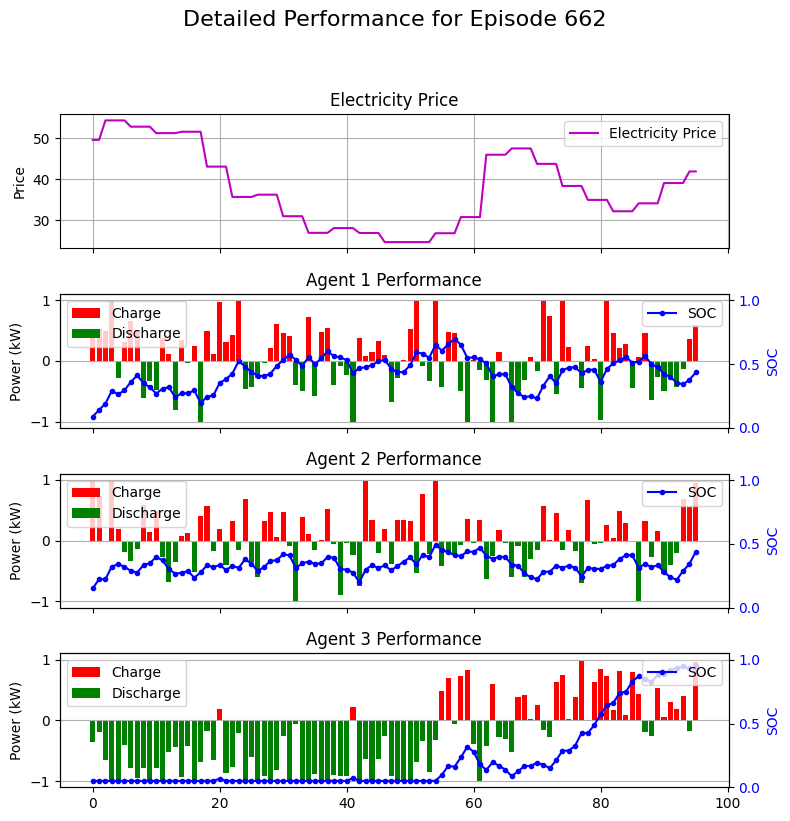

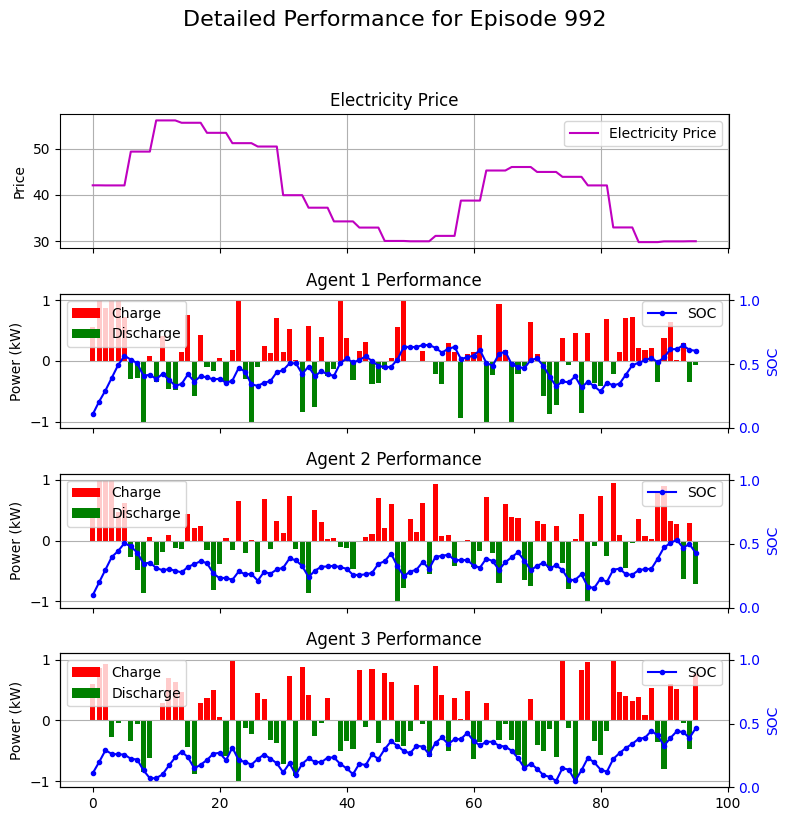

In [4]:
# --- 1. Plot Training Process Analysis ---
print("--- Plotting Training Process Analysis ---")

# (这里把你原来的画图代码原封不动地放进来，记得要注意缩进！)
ep_original_load_cost = [np.sum(ep_data['original_load_cost']) for ep_data in runner.history]
ep_ess_profit = [np.sum(ep_data['ess_profit']) for ep_data in runner.history]
ep_soc_penalty = [np.sum(ep_data['soc_penalty']) for ep_data in runner.history]
ep_peak_valley_penalty = [np.sum(ep_data['peak_valley_penalty']) for ep_data in runner.history]
ep_cost_with_ess = [np.sum(ep_data['cost_with_ess']) for ep_data in runner.history]

window_size = 20

fig, axs = plt.subplots(5, 1, figsize=(8, 8), sharex=True)
fig.suptitle(f'Training Process Analysis for {runner.env_name}', fontsize=16)

# Subplot 1
ax = axs[0]
data_ma = pd.Series(runner.episode_rewards).rolling(window=window_size, min_periods=1).mean()
ax.plot(data_ma, color='red', linewidth=2, label=f'Moving Average (window={window_size})')
ax.set_title("1. Total Reward")
ax.set_ylabel('Value per Episode')
ax.grid(True, linestyle=':')
ax.legend(loc='best')
ax.axhline(0, color='black', linewidth=0.5, linestyle='-')

# Subplot 2
ax = axs[1]
original_cost_ma = pd.Series(ep_original_load_cost).rolling(window=window_size, min_periods=1).mean()
ax.plot(original_cost_ma, color='gray', linestyle='--', linewidth=2, label=f'Original Load Cost (MA-{window_size})')
cost_with_ess_ma = pd.Series(ep_cost_with_ess).rolling(window=window_size, min_periods=1).mean()
ax.plot(cost_with_ess_ma, color='blue', linewidth=2, label=f'Cost with ESS (MA-{window_size})')
ax.set_title("2. Load Costs")
ax.set_ylabel('Value per Episode')
ax.grid(True, linestyle=':')
ax.legend(loc='best')
ax.axhline(0, color='black', linewidth=0.5, linestyle='-')

# Subplot 3
ax = axs[2]
data_ma = pd.Series(ep_ess_profit).rolling(window=window_size, min_periods=1).mean()
ax.plot(data_ma, color='green', linewidth=2, label=f'Moving Average (window={window_size})')
ax.set_title("3. ESS Profit")
ax.set_ylabel('Value per Episode')
ax.grid(True, linestyle=':')
ax.legend(loc='best')
ax.axhline(0, color='black', linewidth=0.5, linestyle='-')

# Subplot 4
ax = axs[3]
data_ma = pd.Series(ep_soc_penalty).rolling(window=window_size, min_periods=1).mean()
ax.plot(data_ma, color='orange', linewidth=2, label=f'Moving Average (window={window_size})')
ax.set_title("4. SOC Penalty")
ax.set_ylabel('Value per Episode')
ax.grid(True, linestyle=':')
ax.legend(loc='best')
ax.axhline(0, color='black', linewidth=0.5, linestyle='-')

# Subplot 5
ax = axs[4]
data_ma = pd.Series(ep_peak_valley_penalty).rolling(window=window_size, min_periods=1).mean()
ax.plot(data_ma, color='purple', linewidth=2, label=f'Moving Average (window={window_size})')
ax.set_title("5. Peak-Valley Penalty")
ax.set_ylabel('Value per Episode')
ax.grid(True, linestyle=':')
ax.legend(loc='best')
ax.axhline(0, color='black', linewidth=0.5, linestyle='-')

axs[-1].set_xlabel('Episode')
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(f"training_analysis_subplots_{runner.env_name}.png")
plt.show()

# --- 2. 可视化指定多个训练回合的数据 ---
print("\n--- Plotting Detailed Results ---")

total_episodes = len(runner.history)
if total_episodes == 0:
    print("No training history found. Please run training first.")
else:
    episodes_to_plot = sorted(set([0, total_episodes // 3, (2 * total_episodes) // 3, total_episodes - 1]))
    print(f"Episodes to plot (1-based): {[e + 1 for e in episodes_to_plot]}")

    for episode_idx in episodes_to_plot:
        if episode_idx >= len(runner.history) or episode_idx < 0:
            print(f"Warning: Episode {episode_idx + 1} not found. Skipping.")
            continue

        episode_data = runner.history[episode_idx]
        price_history = episode_data['price']
        actions_history = episode_data['actions']
        soc_history = episode_data['soc']

        fig, axs = plt.subplots(args.N + 1, 1, figsize=(8, 2 * (args.N + 1)), sharex=True)
        if args.N == 0:
            axs = [axs]

        fig.suptitle(f'Detailed Performance for Episode {episode_idx + 1}', fontsize=16, y=1.02)
        time_steps = np.arange(len(price_history))

        ax_price = axs[0]
        ax_price.plot(time_steps, price_history, 'm-', label='Electricity Price')
        ax_price.set_ylabel('Price')
        ax_price.set_title('Electricity Price')
        ax_price.legend()
        ax_price.grid(True)

        for i in range(args.N):
            ax1 = axs[i + 1]
            charge_power = np.array(actions_history[i])
            ax1.bar(time_steps, np.maximum(0, charge_power), color='r', width=0.8, label='Charge')
            ax1.bar(time_steps, np.minimum(0, charge_power), color='g', width=0.8, label='Discharge')
            ax1.set_ylabel('Power (kW)', color='k')
            ax1.set_title(f'Agent {i+1} Performance')
            ax1.legend(loc='upper left')
            ax1.grid(True, axis='y')

            ax2 = ax1.twinx()
            ax2.plot(time_steps, soc_history[i][1:], 'b-', marker='.', label='SOC')
            ax2.set_ylabel('SOC', color='b')
            ax2.tick_params(axis='y', labelcolor='b')
            ax2.set_ylim(0, 1.05)
            ax2.legend(loc='upper right')

        plt.xlabel('Time Step')
        fig.tight_layout(rect=[0, 0, 1, 0.98])
        plt.show()

# --- 2. 可视化指定多个训练回合的数据 ---
print("\n--- Plotting Detailed Results ---")

total_episodes = len(runner.history)
if total_episodes == 0:
    print("No training history found. Please run training first.")
else:
    episodes_to_plot = sorted(set([0, total_episodes // 3, (2 * total_episodes) // 3, total_episodes - 1]))
    print(f"Episodes to plot (1-based): {[e + 1 for e in episodes_to_plot]}")

    for episode_idx in episodes_to_plot:
        if episode_idx >= len(runner.history) or episode_idx < 0:
            print(f"Warning: Episode {episode_idx + 1} not found. Skipping.")
            continue

        episode_data = runner.history[episode_idx]
        price_history = episode_data['price']
        actions_history = episode_data['actions']
        soc_history = episode_data['soc']

        fig, axs = plt.subplots(args.N + 1, 1, figsize=(8, 2 * (args.N + 1)), sharex=True)
        if args.N == 0:
            axs = [axs]

        fig.suptitle(f'Detailed Performance for Episode {episode_idx + 1}', fontsize=16, y=1.02)
        time_steps = np.arange(len(price_history))

        ax_price = axs[0]
        ax_price.plot(time_steps, price_history, 'm-', label='Electricity Price')
        ax_price.set_ylabel('Price')
        ax_price.set_title('Electricity Price')
        ax_price.legend()
        ax_price.grid(True)

        for i in range(args.N):
            ax1 = axs[i + 1]
            charge_power = np.array(actions_history[i])
            ax1.bar(time_steps, np.maximum(0, charge_power), color='r', width=0.8, label='Charge')
            ax1.bar(time_steps, np.minimum(0, charge_power), color='g', width=0.8, label='Discharge')
            ax1.set_ylabel('Power (kW)', color='k')
            ax1.set_title(f'Agent {i+1} Performance')
            ax1.legend(loc='upper left')
            ax1.grid(True, axis='y')

            ax2 = ax1.twinx()
            ax2.plot(time_steps, soc_history[i][1:], 'b-', marker='.', label='SOC')
            ax2.set_ylabel('SOC', color='b')
            ax2.tick_params(axis='y', labelcolor='b')
            ax2.set_ylim(0, 1.05)
            ax2.legend(loc='upper right')

        plt.xlabel('Time Step')
        fig.tight_layout(rect=[0, 0, 1, 0.98])
        plt.show()